### Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## connecting to the SQL database

In [ ]:
import sqlite3

In [ ]:
#connect to the SQLite database
connection = sqlite3.connect(r'C:\Users\USER\Documents\Amdari\Nordex-Shift-Performance-Optimization\ShiftData.db')
Shift_Data = pd.read_sql("SELECT * FROM ShiftPerformance", connection)
Shift_Data.head()

,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,...,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00


### Basic Dataset Overview
* Shift_Data.columns - Get Data Column
* Shift_Data.Shape - Data shape
* Shift_Data.isna()Check for missing Data
* Shift_Data.duplicates()-Check for duplicate
* Shift_Data.datatime()-Format Date into proper Date format
* Check for statical Distribution of the Data

In [ ]:
Shift_Data.columns

Index(['shift_id', 'shift_name', 'start_time', 'end_time', 'supervisor_id',
       'production_id', 'date', 'units_produced', 'defect_count',
       'cycle_time_avg', 'shift_efficiency_score', 'operator_id',
       'operator_name', 'experience_level', 'skill_category', 'machine_id',
       'runtime_hours', 'downtime_minutes', 'maintenance_flag',
       'machine_status', 'maintenance_id', 'issue_type',
       'maintenance_downtime', 'resolved_by', 'qc_id', 'defect_type',
       'severity', 'inspection_result', 'temperature', 'humidity',
       'timestamp'],
      dtype='object')

In [ ]:
Shift_Data.shape

(296334, 31)

In [ ]:
Shift_Data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   shift_id                296334 non-null  int64  
 1   shift_name              296334 non-null  object 
 2   start_time              296334 non-null  object 
 3   end_time                296334 non-null  object 
 4   supervisor_id           296334 non-null  object 
 5   production_id           296334 non-null  int64  
 6   date                    296334 non-null  object 
 7   units_produced          296334 non-null  int64  
 8   defect_count            296334 non-null  int64  
 9   cycle_time_avg          296334 non-null  float64
 10  shift_efficiency_score  296334 non-null  float64
 11  operator_id             296334 non-null  object 
 12  operator_name           296334 non-null  object 
 13  experience_level        296334 non-null  int64  
 14  skill_category      

In [ ]:
Shift_Data['date'] = pd.to_datetime(Shift_Data['date'])
Shift_Data['start_time'] = pd.to_datetime(Shift_Data['start_time'])
Shift_Data['end_time'] = pd.to_datetime(Shift_Data['end_time'])
Shift_Data['timestamp'] = pd.to_datetime(Shift_Data['timestamp'])

C:\Users\USER\AppData\Local\Temp\ipykernel_10768\1450105613.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Shift_Data['start_time'] = pd.to_datetime(Shift_Data['start_time'])
C:\Users\USER\AppData\Local\Temp\ipykernel_10768\1450105613.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Shift_Data['end_time'] = pd.to_datetime(Shift_Data['end_time'])


In [ ]:
Shift_Data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334

In [ ]:
#To check duplicate data
Shift_Data.duplicated().sum()

np.int64(0)

In [ ]:
#to check for missing values
Shift_Data.isnull().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                 1205
humidity                    1205
timestamp 

In [ ]:
Shift_Data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                 1205
humidity                    1205
timestamp 

In [ ]:
#To check statistical distribution of numerical columns
Shift_Data.describe()


,shift_id,start_time,end_time,production_id,date,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,runtime_hours,downtime_minutes,maintenance_flag,maintenance_id,maintenance_downtime,qc_id,temperature,humidity,timestamp
count,296334.000000,296334,296334,296334.000000,296334,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,115231.000000,115231.000000,296334.00000,295129.000000,295129.000000,295129
mean,2.048142,2026-06-14 14:23:06.478770688,2026-06-14 13:57:27.318228736,6777.751567,2024-02-14 16:00:58.312579584,634.718962,20.667409,36.018468,75.551615,4.059531,6.664388,50.130673,0.181711,937.577969,53.545726,138756.82872,20.901223,44.593118,2024-02-15 04:22:59.795276288
min,1.000000,2026-06-14 06:00:00,2026-06-14 06:00:00,1.000000,2024-01-01 00:00:00,414.000000,13.000000,32.000000,41.690033,1.000000,5.900000,10.000000,0.000000,1.000000,10.000000,1.00000,17.000000,30.000000,2024-01-01 08:00:00
25%,1.000000,2026-06-14 06:00:00,2026-06-14 06:00:00,3350.000000,2024-01-23 00:00:00,506.000000,18.000000,34.650000,64.280117,2.000000,6.430000,35.980000,0.000000,457.000000,38.300000,70076.25000,19.900000,38.700000,2024-01-23 08:00:00
50%,2.000000,2026-06-14 14:00:00,2026-06-14 14:00:00,6747.000000,2024-02-14 00:00:00,596.000000,21.000000,36.000000,75.963017,4.000000,6.620000,52.680000,0.000000,932.000000,55.840000,139062.50000,20.900000,44.500000,2024-02-15 00:00:00
75%,3.000000,2026-06-14 22:00:00,2026-06-14 22:00:00,10200.750000,2024-03-08 18:00:00,801.000000,23.000000,37.360000,87.208274,5.000000,6.900000,64.490000,0.000000,1414.000000,69.800000,207680.75000,21.900000,50.300000,2024-03-09 00:00:00
max,3.000000,2026-06-14 22:00:00,2026-06-14 22:00:00,13650.000000,2024-03-31 00:00:00,972.000000,29.000000,42.000000,104.379285,12.000000,7.330000,95.710000,1.000000,1897.000000,95.710000,276245.00000,25.000000,65.000000,2024-03-31 16:00:00
std,0.807365,NaN,NaN,3952.136116,NaN,152.655935,2.924631,1.969414,12.928116,2.437622,0.324082,19.454400,0.385606,549.669218,19.065400,79691.21252,1.524821,7.756084,NaN


### Filling missing value

* df.isna().sum() - To check for missing value
* df.sort_values(by="date") - sort the dataset chronology,which is essential for timeseries before using forward method of filling missing values
* filling values with last know values and also using mean

In [ ]:
Shift_Data= Shift_Data.sort_values(by='date')

#fill temp and humidity with forward fill method
Shift_Data['temperature'] = Shift_Data['temperature'].fillna(method='ffill').fillna(Shift_Data['temperature'].mean())
Shift_Data['humidity'] = Shift_Data['humidity'].fillna(method='ffill').fillna(Shift_Data['humidity'].mean())
#fiLL timestamp with forward fill method
Shift_Data['timestamp']= Shift_Data['timestamp'].fillna(method='ffill')

C:\Users\USER\AppData\Local\Temp\ipykernel_10768\3757884815.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Shift_Data['temperature'] = Shift_Data['temperature'].fillna(method='ffill').fillna(Shift_Data['temperature'].mean())
C:\Users\USER\AppData\Local\Temp\ipykernel_10768\3757884815.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Shift_Data['humidity'] = Shift_Data['humidity'].fillna(method='ffill').fillna(Shift_Data['humidity'].mean())
C:\Users\USER\AppData\Local\Temp\ipykernel_10768\3757884815.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Shift_Data['timestamp']= Shift_Data['timestamp'].fillna(method='ffill')


In [ ]:
Shift_Data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                    0
humidity                       0
timestamp 

In [ ]:
#Filling the categorical columns with the mode

Shift_Data['issue_type'] = Shift_Data['issue_type'].fillna('No Issue')
Shift_Data['resolved_by'] = Shift_Data['resolved_by'].fillna('No Maintenance')
#filling the downtime col
Shift_Data['maintenance_downtime'] = Shift_Data['maintenance_downtime'].fillna(0)
Shift_Data= Shift_Data.drop(columns=["maintenance_id"])

In [ ]:
Shift_Data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 296334 entries, 0 to 296333
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334 non-

In [ ]:
Shift_Data.isna().sum()

shift_id                  0
shift_name                0
start_time                0
end_time                  0
supervisor_id             0
production_id             0
date                      0
units_produced            0
defect_count              0
cycle_time_avg            0
shift_efficiency_score    0
operator_id               0
operator_name             0
experience_level          0
skill_category            0
machine_id                0
runtime_hours             0
downtime_minutes          0
maintenance_flag          0
machine_status            0
issue_type                0
maintenance_downtime      0
resolved_by               0
qc_id                     0
defect_type               0
severity                  0
inspection_result         0
temperature               0
humidity                  0
timestamp                 0
dtype: int64

In [ ]:
Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296334 entries, 0 to 296333
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334 non-

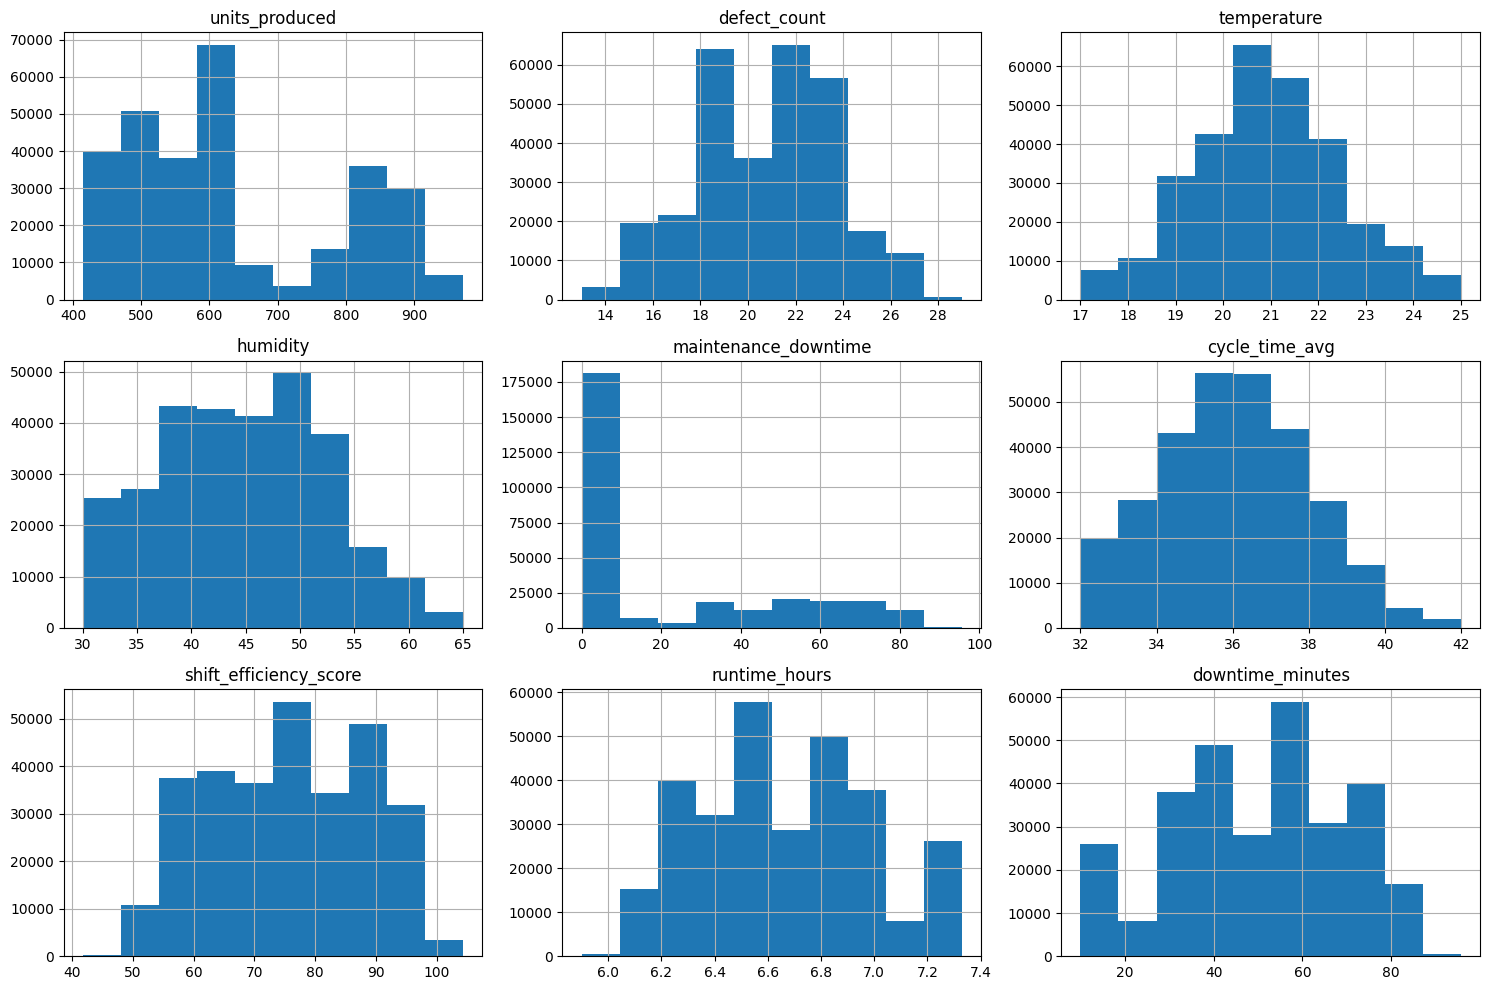

In [ ]:
#Numerical Data analysis

num_cols = ["units_produced","defect_count",
            "temperature","humidity","maintenance_downtime",
            "cycle_time_avg","shift_efficiency_score","runtime_hours",
            "downtime_minutes"
            ]

Shift_Data[num_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

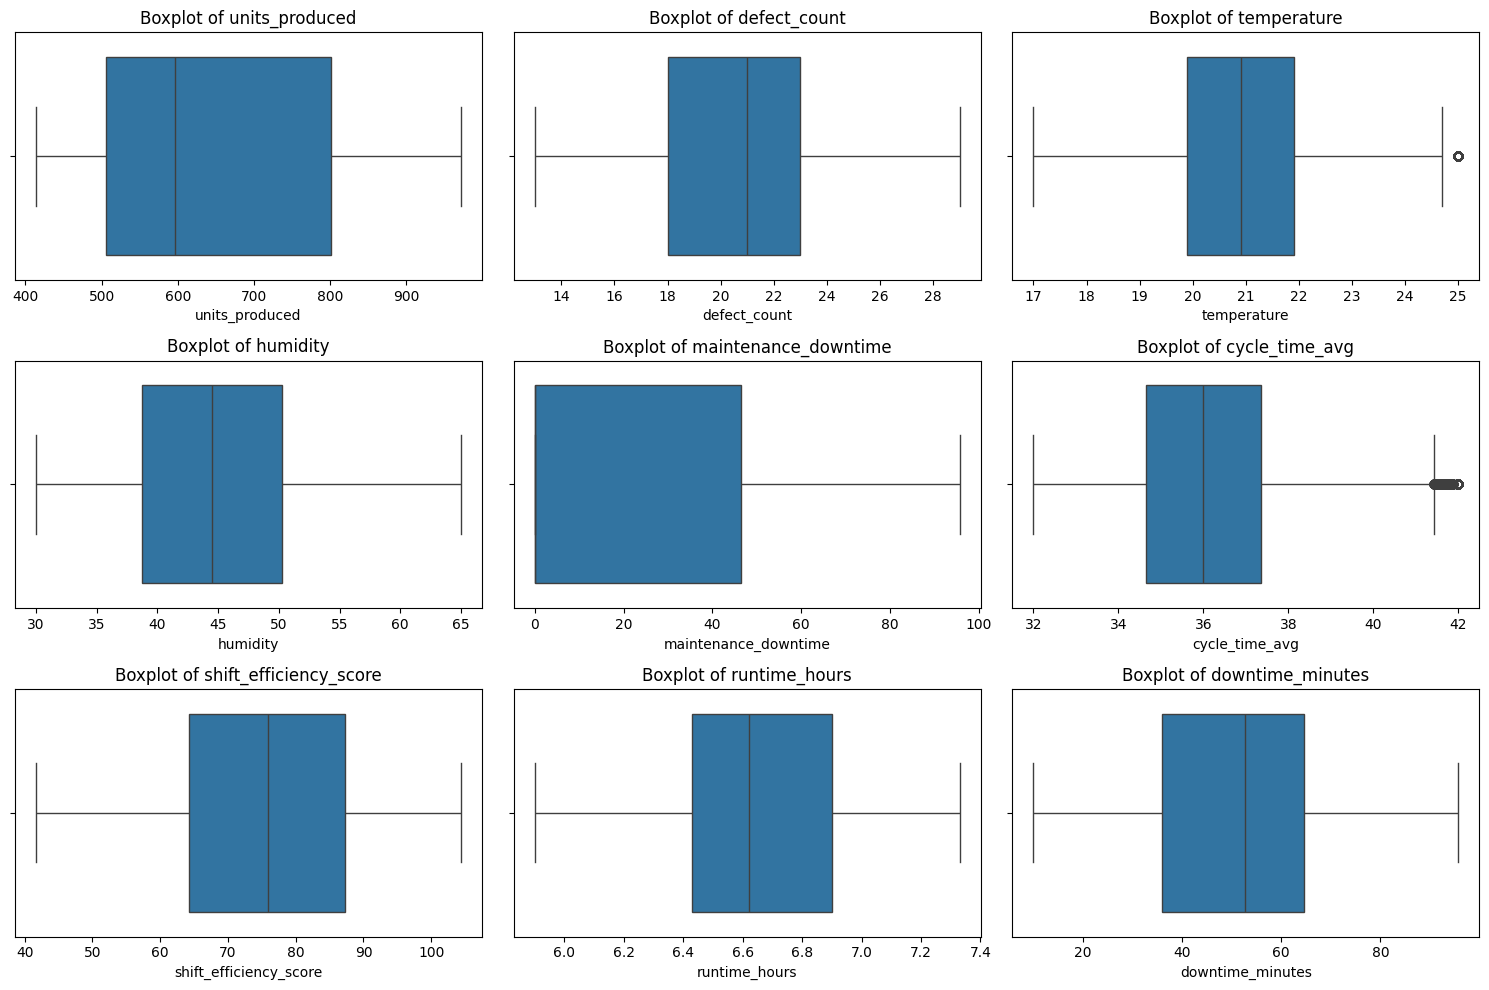

In [ ]:
#to check if numerical data in Dataset has outliers
plt.figure(figsize=(15,10))
for  i,col in enumerate(num_cols):
    plt.subplot(3,3,i+1)
    sns.boxplot(x=Shift_Data[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

### Categorical Analysis

In [ ]:
Categorical_cols=["shift_name","issue_type","resolved_by",
                  "machine_status","defect_type","inspection_result","severity","experience_level"]
for col in Categorical_cols:
    print(f"Value counts for {col}:\n")
    print(Shift_Data[col].value_counts())
    print("\n")

Value counts for shift_name:

shift_name
Night      104057
Evening    102486
Morning     89791
Name: count, dtype: int64


Value counts for issue_type:

issue_type
No Issue       181103
Mechanical      40521
Electrical      28957
Calibration     18508
Software        16238
Preventive      11007
Name: count, dtype: int64


Value counts for resolved_by:

resolved_by
No Maintenance    181103
TECH_03            12537
TECH_07            12427
TECH_08            12290
TECH_02            12065
TECH_10            11977
TECH_05            11743
TECH_04            11275
TECH_01            10522
TECH_09            10441
TECH_06             9954
Name: count, dtype: int64


Value counts for machine_status:

machine_status
Issues         173712
Operational    122622
Name: count, dtype: int64


Value counts for defect_type:

defect_type
Dimensional    59777
Surface        59376
Assembly       59288
Cosmetic       59227
Material       58666
Name: count, dtype: int64


Value counts for inspection_resul

C:\Users\USER\AppData\Local\Temp\ipykernel_10768\3784759032.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='count', data=counts,palette="coolwarm" ,ax=axes[index])
C:\Users\USER\AppData\Local\Temp\ipykernel_10768\3784759032.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='count', data=counts,palette="coolwarm" ,ax=axes[index])
C:\Users\USER\AppData\Local\Temp\ipykernel_10768\3784759032.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='count', data=counts,palette="coolwarm" ,ax=axes[index])
C:\Users\USER

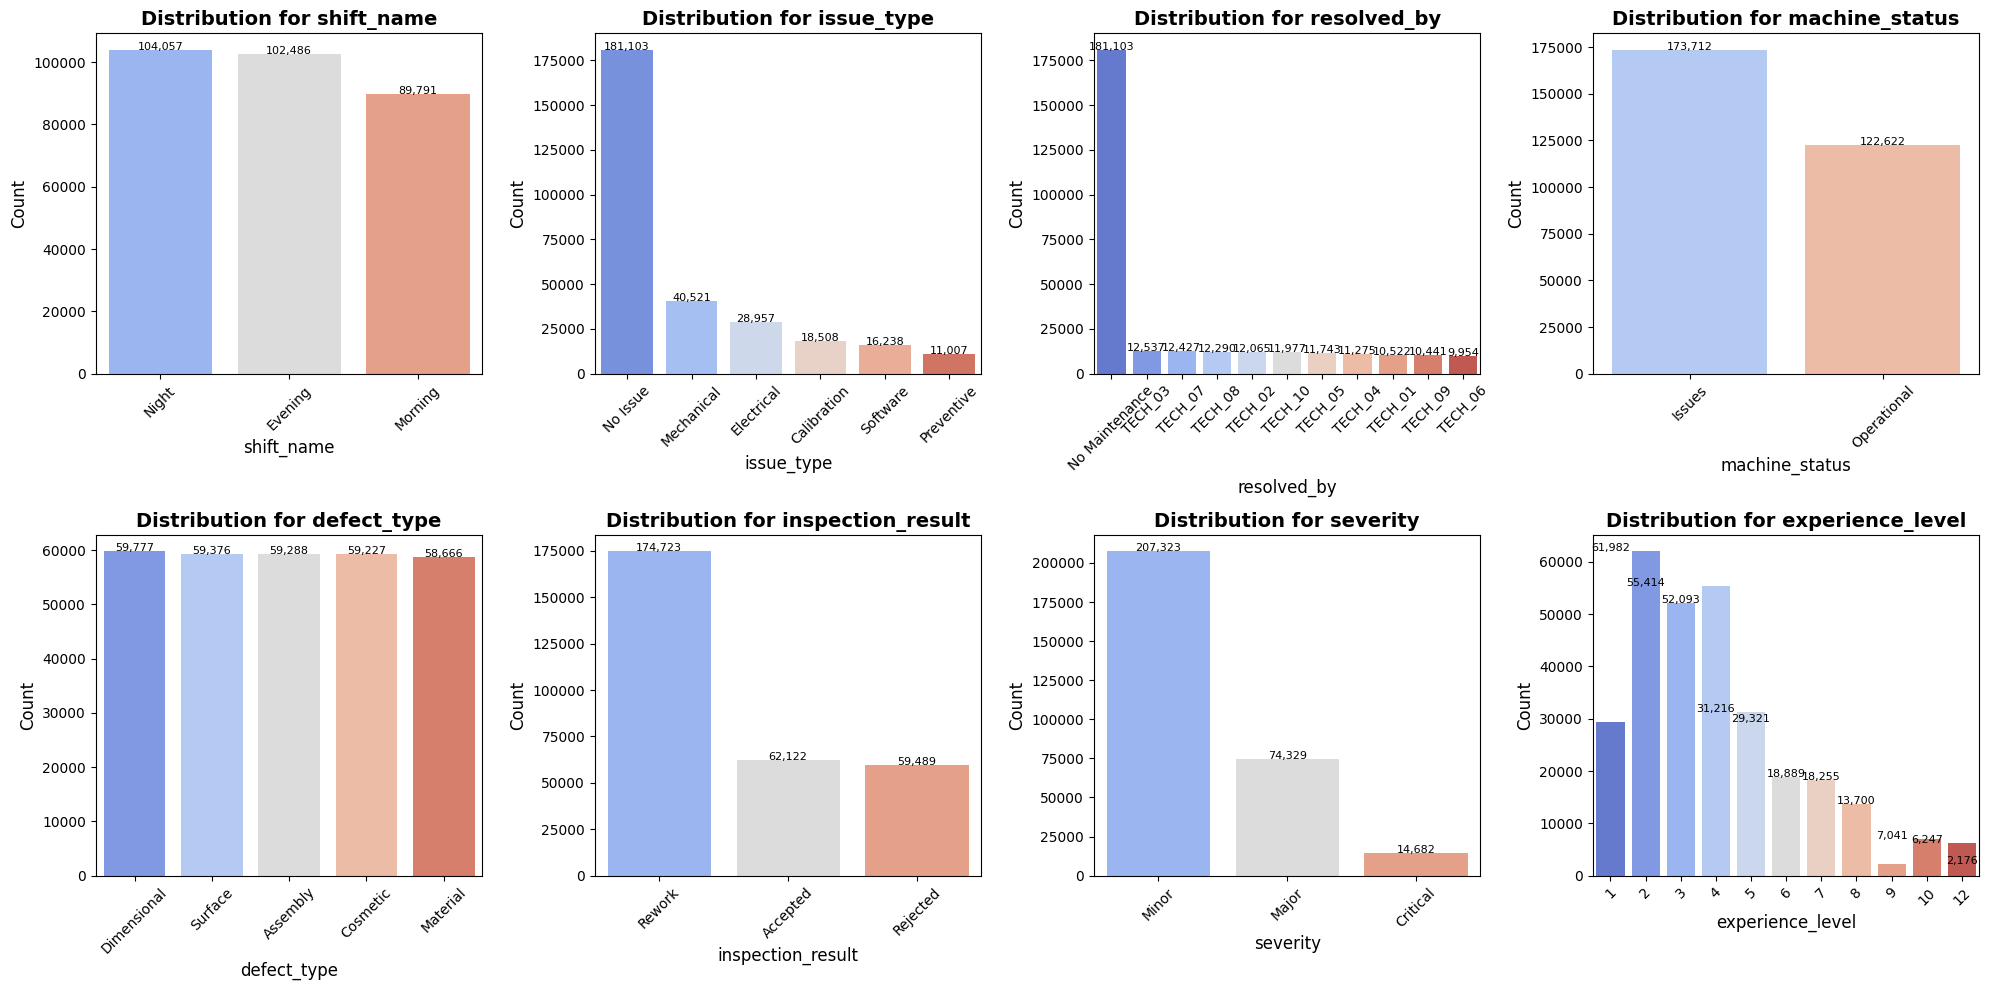

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for index, col in enumerate(Categorical_cols):
    #Get the value counts 
    counts=Shift_Data[col].value_counts().reset_index()
    counts.columns=[col, 'count']
    sns.barplot(x=col, y='count', data=counts,palette="coolwarm" ,ax=axes[index])
    axes[index].set_title(f'Distribution for {col}', fontsize=14,fontweight='bold')
    axes[index].tick_params(axis='x', rotation=45)
    axes[index].set_xlabel(col, fontsize=12)
    axes[index].set_ylabel('Count', fontsize=12)
    
    #adding value labels on top of bars
    for j,v in enumerate(counts['count']):
        axes[index].text(j, v, f'{v:,}',ha='center', fontsize=8)
        
plt.tight_layout()
plt.show()

### Operational perform during; Maintenance and No Maintenance

In [ ]:
Shift_Data['maintenance_flag'].value_counts()

maintenance_flag
0    242487
1     53847
Name: count, dtype: int64

In [ ]:
#Maintenance flag Analysis
maintenance_data= Shift_Data.groupby('maintenance_flag')[num_cols].mean().reset_index()

In [ ]:
maintenance_data.head()

,maintenance_flag,units_produced,defect_count,temperature,humidity,maintenance_downtime,cycle_time_avg,shift_efficiency_score,runtime_hours,downtime_minutes
0,0,641.509524,20.593933,20.900962,44.572548,13.520254,36.016664,76.106388,6.678512,49.281488
1,1,604.139302,20.998291,20.860356,44.613007,53.701075,36.026591,73.053327,6.600786,53.954773


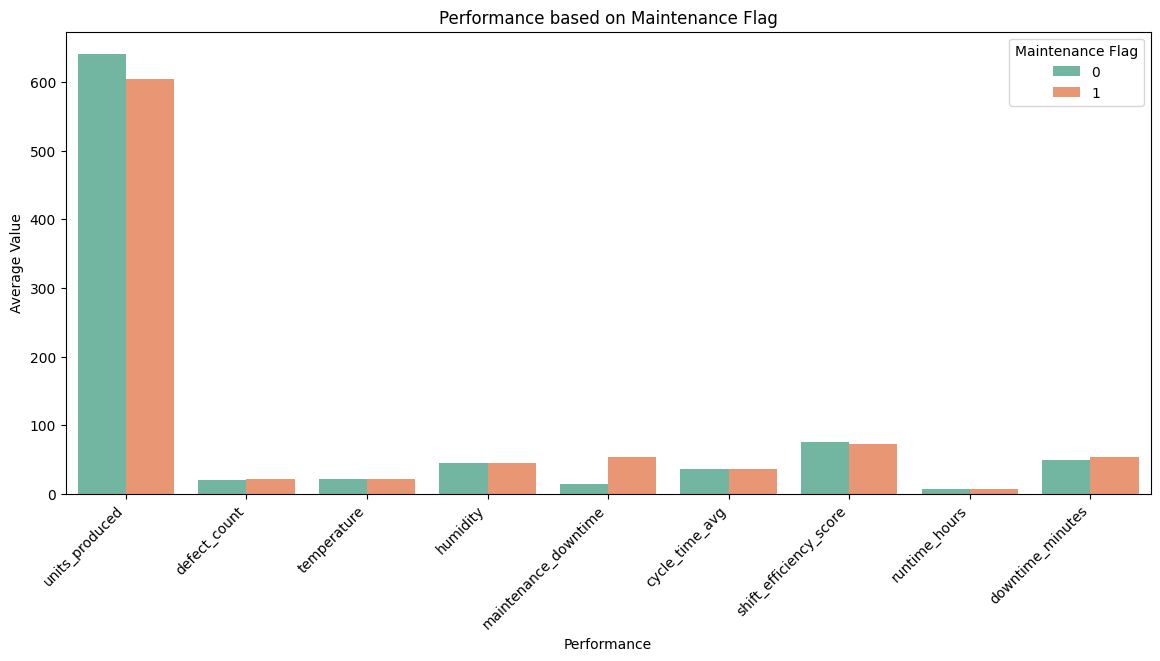

In [ ]:
maintenance_data_melt = maintenance_data.melt(
    id_vars=['maintenance_flag'], var_name='Performance', value_name='Average Value')

plt.figure(figsize=(14, 6))
sns.barplot(data=maintenance_data_melt, x='Performance', y='Average Value', hue='maintenance_flag', palette='Set2')
plt.xticks(rotation=45,ha='right')
plt.xlabel('Performance')
plt.ylabel('Average Value')
plt.title('Performance based on Maintenance Flag')
plt.legend(title='Maintenance Flag')
plt.show()


### Shfit Performance Analysis


In [ ]:
Shift_performance_data= Shift_Data.groupby('shift_name').agg({
    "units_produced": ["mean", "sum"],
    "cycle_time_avg": "mean",
    "defect_count": "mean",
    "downtime_minutes": ["mean", "sum"],
    "shift_efficiency_score": "mean"
}).reset_index()


Shift_performance_data.columns = [
    'shift_name', 'average_units_produced', 'total_units_produced', 
    'avg_cycle_time', 'avg_defect_count', 'avg_downtime_minutes',
    'total_downtime_minutes', 'avg_efficiency']

#calculate the defect rate
defect_sum = Shift_Data.groupby('shift_name')['defect_count'].sum().values
units_sum = Shift_Data.groupby('shift_name')['units_produced'].sum().values
Shift_performance_data['defect_rate'] = (defect_sum / units_sum) * 100

Shift_performance_data.sort_values(by='average_units_produced', ascending=False)

,shift_name,average_units_produced,total_units_produced,avg_cycle_time,avg_defect_count,avg_downtime_minutes,total_downtime_minutes,avg_efficiency,defect_rate
1,Morning,846.926073,76046339,35.999287,18.749151,29.086002,2611661.18,90.869944,2.213788
0,Evening,601.050543,61599266,36.025551,21.329079,50.569570,5182672.96,76.737957,3.548633
2,Night,484.765119,50443204,36.028043,21.670998,67.857893,7061088.73,61.164965,4.470412


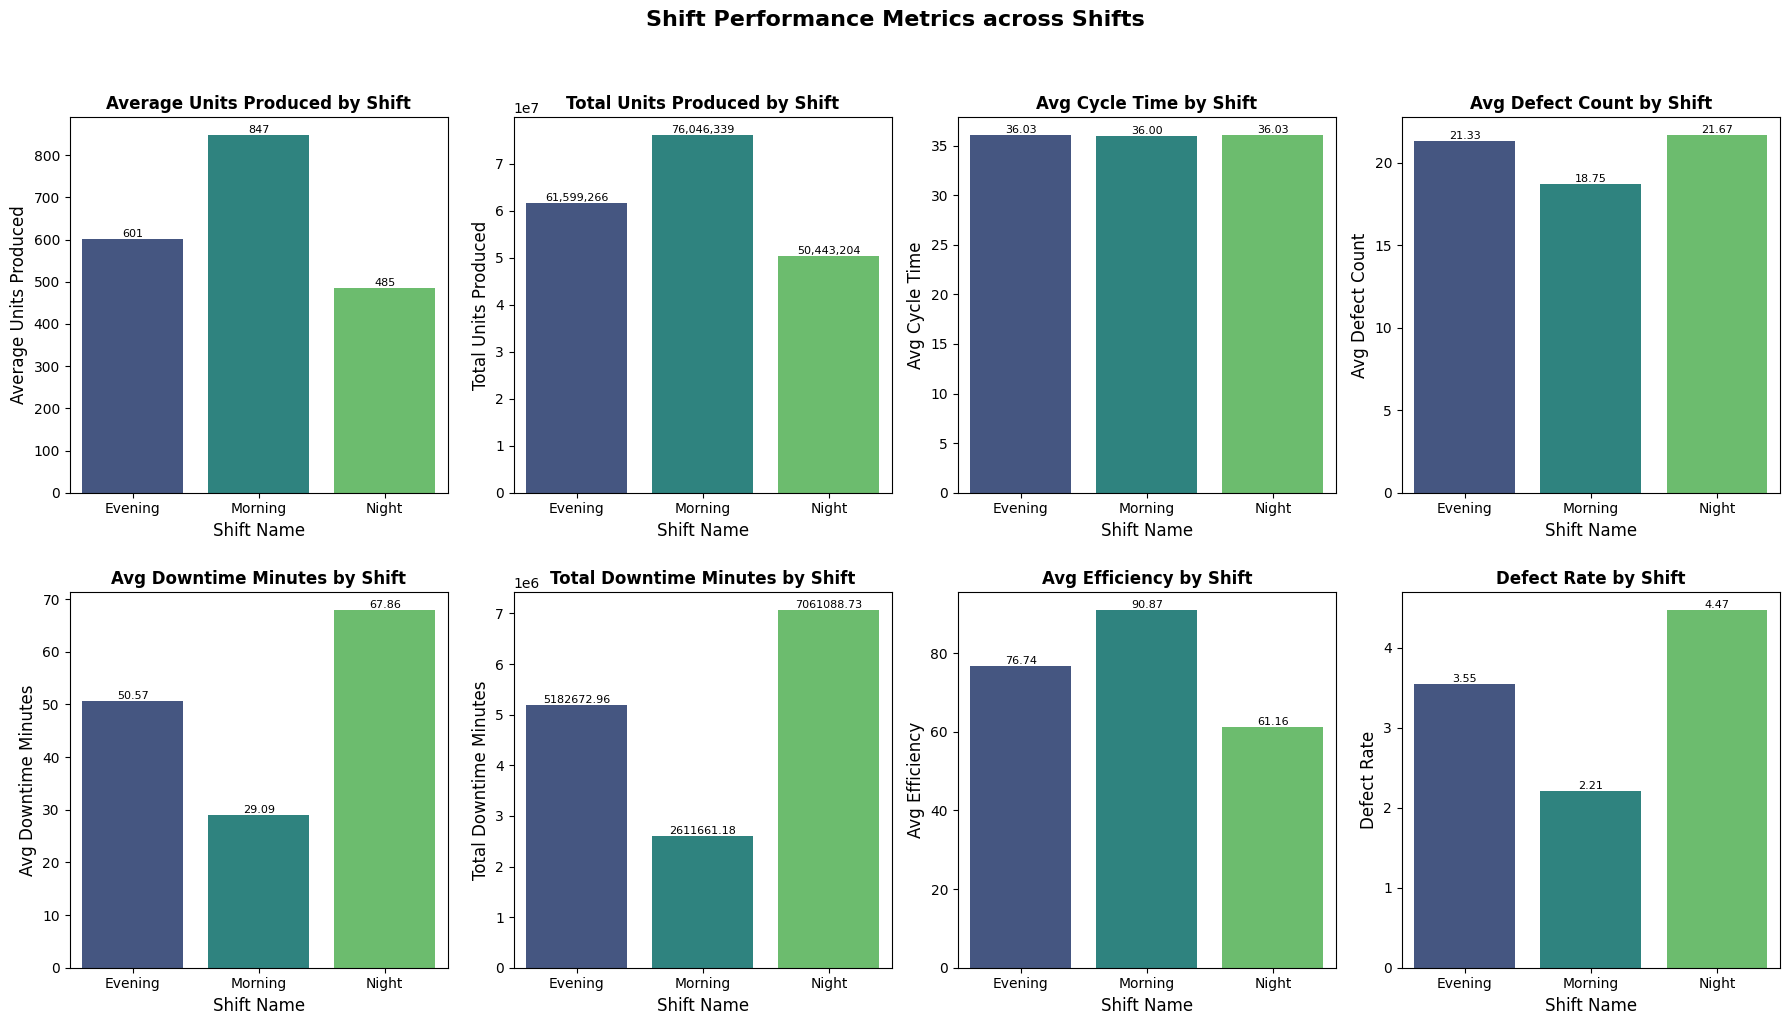

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

metrics = ["average_units_produced","total_units_produced",
           "avg_cycle_time", "avg_defect_count",
           "avg_downtime_minutes","total_downtime_minutes","avg_efficiency","defect_rate"]

for i, metric in enumerate(metrics):
    sns.barplot(x='shift_name', y=metric, 
                hue='shift_name', palette='viridis', 
                data=Shift_performance_data, ax=axes[i])
    axes[i].set_title(f'{metric.replace("_", " ").title()} by Shift', fontsize=12,fontweight='bold')
    axes[i].set_xlabel('Shift Name', fontsize=12)
    axes[i].set_ylabel(metric.replace("_", " ").title(), fontsize=12)
    
    for j, v in enumerate(Shift_performance_data[metric]):
        if "units" in metric:
            axes[i].text(j, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=8)
        else:
            axes[i].text(j, v, f'{v:.2f}', ha='center', va='bottom', fontsize=8)
    
plt.suptitle('Shift Performance Metrics across Shifts', fontsize=16, fontweight='bold',y=1.02)
plt.tight_layout()
plt.show()


### Shift Performance based on Production Per Hour

In [ ]:
Shift_Data["total_operation_time"] = Shift_Data["runtime_hours"] + (Shift_Data["downtime_minutes"] / 60)

output_per_hour = (
    Shift_Data.groupby('shift_name')
    .apply(lambda x: x["units_produced"].sum() / x["total_operation_time"].sum())
    .rename("output_per_hour")
)

output_per_hour

C:\Users\USER\AppData\Local\Temp\ipykernel_10768\974962164.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["units_produced"].sum() / x["total_operation_time"].sum())


shift_name
Evening     80.140742
Morning    112.927525
Night       64.635285
Name: output_per_hour, dtype: float64

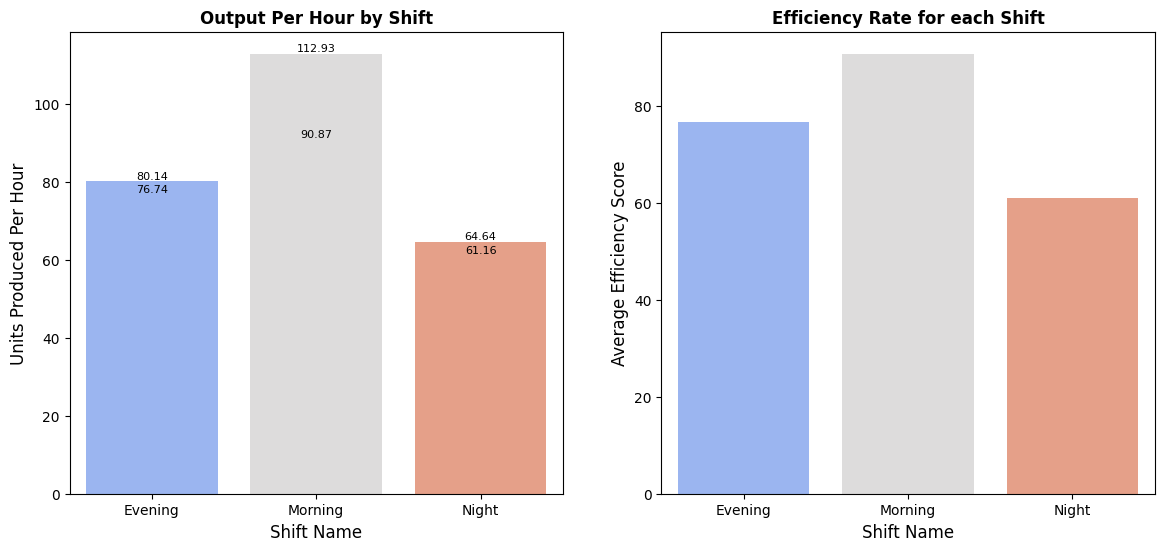

In [ ]:
output_per_hour_data = output_per_hour.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=output_per_hour_data, x='shift_name',hue="shift_name",
            y="output_per_hour", palette="coolwarm",
            ax=axes[0],legend=False)

axes[0].set_title('Output Per Hour by Shift', fontsize=12,fontweight='bold')
axes[0].set_xlabel('Shift Name', fontsize=12)
axes[0].set_ylabel('Units Produced Per Hour', fontsize=12)
for i,v in enumerate(output_per_hour_data['output_per_hour']):
    axes[0].text(i, v, f"{v:.2f}", ha='center', va='bottom', fontsize=8)
    
    
merged_data = Shift_performance_data.merge(output_per_hour_data,on="shift_name")
#PLot 2 
sns.barplot(data=merged_data, x='shift_name',hue="shift_name",
            y="avg_efficiency", palette="coolwarm",
            ax=axes[1],legend=False)

axes[1].set_title('Efficiency Rate for each Shift', fontsize=12,fontweight='bold')
axes[1].set_xlabel('Shift Name', fontsize=12)
axes[1].set_ylabel('Average Efficiency Score', fontsize=12)
for i,v in enumerate(merged_data['avg_efficiency']):
    axes[0].text(i, v, f"{v:.2f}", ha='center', va='bottom', fontsize=8)
    

In [ ]:
production = (
    Shift_Data[["production_id","shift_id","date","units_produced","defect_count"]]
    .drop_duplicates(subset=["production_id"])
    .copy()
)


machine = (
    Shift_Data[["machine_id", "date","shift_id","downtime_minutes"]]
)

In [ ]:
production.head()

,production_id,shift_id,date,units_produced,defect_count
0,1,1,2024-01-01,929,20
2308,102,3,2024-01-01,530,21
2309,103,3,2024-01-01,489,22
2331,104,3,2024-01-01,527,21
2281,101,3,2024-01-01,555,21


In [ ]:
production.shape

(13650, 5)

In [ ]:
machine.head()

,machine_id,date,shift_id,downtime_minutes
0,MC_001,2024-01-01,1,15.39
2308,MC_002,2024-01-01,3,53.73
2309,MC_003,2024-01-01,3,51.90
2310,MC_003,2024-01-01,3,51.90
2311,MC_003,2024-01-01,3,51.90


In [ ]:
machine.shape


(296334, 4)

### OEE MARKDOWN CALCULATINS

In [ ]:
import os

PLANNED = globals().get('PLANNED_H',7.5)
THEO = globals().get('THEO_RATE',100.0)

#Computer per machine availability
machine['available_machine'] = 1 - machine['downtime_minutes'] / (PLANNED * 60)
machine['available_machine'] = machine['available_machine'].clip(0,1)

available_machine_agg = (
    machine.groupby(['date', 'shift_id'])['available_machine']
    .mean()
    .reset_index()
    .rename(columns={'available_machine':'machine_availability'})
)

C:\Users\USER\AppData\Local\Temp\ipykernel_10768\1048844606.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  machine['available_machine'] = 1 - machine['downtime_minutes'] / (PLANNED * 60)
C:\Users\USER\AppData\Local\Temp\ipykernel_10768\1048844606.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  machine['available_machine'] = machine['available_machine'].clip(0,1)


In [ ]:
available_machine_agg.head()

,date,shift_id,machine_availability
0,2024-01-01,1,0.962899
1,2024-01-01,2,0.921416
2,2024-01-01,3,0.881914
3,2024-01-02,1,0.965129
4,2024-01-02,2,0.919751


In [ ]:
available_machine_agg.shape

(273, 3)

In [ ]:
#merging availability into production
merged_production_data = production.merge(available_machine_agg,how= "left",on=['date','shift_id'])
merged_production_data['machine_availability'] =merged_production_data['machine_availability'].fillna(1)

#performance based on planned time
merged_production_data["performance"] = (merged_production_data['units_produced'] / (THEO *PLANNED)).clip(0,1)

#Quality
merged_production_data['quality'] = 1 - merged_production_data['defect_count'] / merged_production_data['units_produced']
merged_production_data['quality'] = merged_production_data['quality'].fillna(1).clip(0,1)

#Final OEE result
merged_production_data['oee_est'] =merged_production_data['machine_availability'] * merged_production_data["performance"] * merged_production_data['quality']

merged_production_data['month'] = merged_production_data['date'].dt.month

In [ ]:
merged_production_data.head()

,production_id,shift_id,date,units_produced,defect_count,machine_availability,performance,quality,oee_est,month
0,1,1,2024-01-01,929,20,0.962899,1.000000,0.978471,0.942169,1
1,102,3,2024-01-01,530,21,0.881914,0.706667,0.960377,0.598526,1
2,103,3,2024-01-01,489,22,0.881914,0.652000,0.955010,0.549138,1
3,104,3,2024-01-01,527,21,0.881914,0.702667,0.960152,0.594998,1
4,101,3,2024-01-01,555,21,0.881914,0.740000,0.962162,0.627923,1


In [ ]:
#monthly OEE (overall equipment effective for each month)
monthly_oee = (
    merged_production_data.groupby('month')["oee_est"]
    .mean()
    .sort_index()
)

#to confirm value match with earlier value
for month, value in monthly_oee.items():
    print(f"Month{month} OEE {value*100 :.2f}%")

Month1 OEE 74.90%
Month2 OEE 68.55%
Month3 OEE 68.84%


In [ ]:
monthly_oee.head()

month
1    0.749041
2    0.685464
3    0.688426
Name: oee_est, dtype: float64

In [ ]:
if 1 in monthly_oee.index and 3 in monthly_oee.index:
    m1 = monthly_oee.loc[1]
    m3 = monthly_oee.loc[3]
    degradation = (m1 - m3)/m1 * 100
    print (f"Quartely degradation (month 1 -> month 3):{degradation :.2f}")
else:
    print("COuld not find month 1 and month 3 in the data to compute the degradation process or curve")

Quartely degradation (month 1 -> month 3):8.09


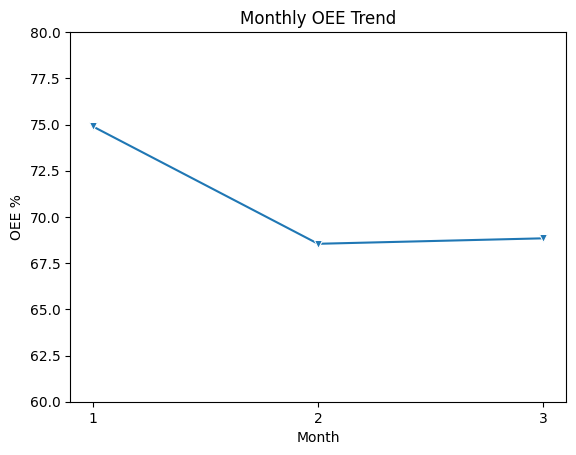

In [ ]:
monthly_oee_df = monthly_oee.reset_index()
monthly_oee_df["OEE_percentage"] = monthly_oee_df["oee_est"] * 100

sns.lineplot (x='month',y='OEE_percentage',data= monthly_oee_df,marker= 'v')
plt.title("Monthly OEE Trend")
plt.ylabel('OEE %')
plt.ylim(60,80)
plt.xlabel('Month')
plt.xticks([1,2,3])
plt.show()

### Experience VS the Defect count that occurs during production


C:\Users\USER\AppData\Local\Temp\ipykernel_10768\1776386678.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=Shift_Data,x='experience_level',y='defect_count',palette='Set2')


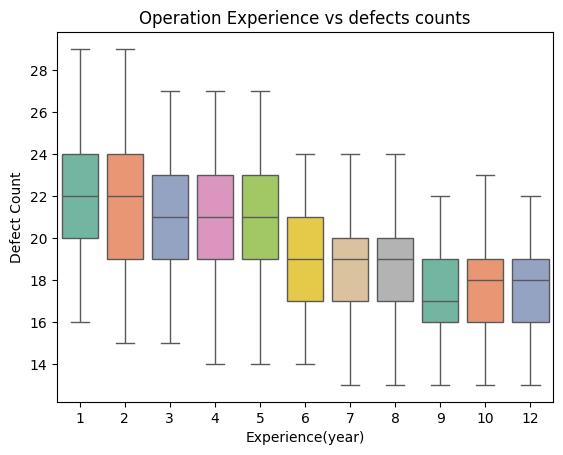

In [ ]:
sns.boxplot(data=Shift_Data,x='experience_level',y='defect_count',palette='Set2')
plt.title('Operation Experience vs defects counts')
plt.xlabel("Experience(year)")
plt.ylabel("Defect Count")
plt.show()

### Feature Enginerring

In [ ]:
import pandas as pd

Shift_Data['start_time'] = pd.to_datetime(Shift_Data['start_time'])
Shift_Data['end_time'] = pd.to_datetime(Shift_Data['end_time'])
Shift_Data['date'] = pd.to_datetime(Shift_Data['date'])

#fixing the overnight shift issue by adding 1 day to end_time if end_time is less than start_time
mask = Shift_Data['end_time'] < Shift_Data['start_time']
Shift_Data.loc[mask, 'end_time'] = Shift_Data.loc[mask, 'end_time'] + pd.Timedelta(days=1)

#Shift Time
Shift_Data['shift_duration'] = (Shift_Data['end_time'] - Shift_Data['start_time']).dt.total_seconds() / 3600

#Defect Rate
Shift_Data['defect_rate'] = Shift_Data['defect_count'] / Shift_Data['units_produced'].replace(0, pd.NA)

Shift_Data['downtime_ratio'] = Shift_Data['downtime_minutes'] / (Shift_Data['shift_duration'] * 60)

#Temporal Features
Shift_Data['day_of_week'] = Shift_Data['date'].dt.dayofweek
Shift_Data['hour_of_day'] = Shift_Data['start_time'].dt.hour

In [ ]:
#drop identifier,leakages and raw datetime columns
columns_to_drop = [
    #identifiers
    "production_id", "machine_id", "shift_id","operator_id","operator_name",
    #leakages
    'qc_id','resolved_by','timestamp',
    #Raw datetime columns
    "date", "start_time", "end_time"
    ]

Shift_Data.drop(columns=columns_to_drop,inplace = True)

In [ ]:
Shift_Data.duplicated().sum()

np.int64(119015)

In [ ]:
Shift_Data.drop_duplicates(inplace=True)

In [ ]:
Shift_Data.duplicated().sum()

np.int64(0)

## Modelling Phase

In [ ]:
Shift_Data.isna().sum()

shift_name                0
supervisor_id             0
units_produced            0
defect_count              0
cycle_time_avg            0
shift_efficiency_score    0
experience_level          0
skill_category            0
runtime_hours             0
downtime_minutes          0
maintenance_flag          0
machine_status            0
issue_type                0
maintenance_downtime      0
defect_type               0
severity                  0
inspection_result         0
temperature               0
humidity                  0
total_operation_time      0
shift_duration            0
defect_rate               0
downtime_ratio            0
day_of_week               0
hour_of_day               0
dtype: int64

In [ ]:
Shift_Data.head()

,shift_name,supervisor_id,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,skill_category,runtime_hours,downtime_minutes,...,severity,inspection_result,temperature,humidity,total_operation_time,shift_duration,defect_rate,downtime_ratio,day_of_week,hour_of_day
0,Morning,SUP_01,929,20,35.65,95.945255,7,Expert,7.24,15.39,...,Minor,Rework,22.3,49.9,7.4965,8.0,0.021529,0.032063,0,6
2308,Night,SUP_03,530,21,35.61,66.604731,5,Intermediate,6.60,53.73,...,Minor,Accepted,22.3,49.9,7.4955,8.0,0.039623,0.111937,0,22
2309,Night,SUP_03,489,22,34.01,61.238523,2,Junior,6.64,51.90,...,Major,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22
2310,Night,SUP_03,489,22,34.01,61.238523,2,Junior,6.64,51.90,...,Minor,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22
2311,Night,SUP_03,489,22,34.01,61.238523,2,Junior,6.64,51.90,...,Minor,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22


In [ ]:
Shift_Data['shift_efficiency_score'].describe()

count    177319.000000
mean         75.829886
std          12.955768
min          41.690033
25%          64.595342
50%          76.253965
75%          87.578778
max         104.379285
Name: shift_efficiency_score, dtype: float64

In [ ]:
#remove the one you think is not relevant for the model or has high cardinality or has data leakage
Shift_Data.drop(['supervisor_id',"inspection_result",
                 "severity","defect_rate","downtime_ratio",'day_of_week','hour_of_day'], axis=1, inplace=True)
#dropping this due to that the model is expect to predict efficiency beforw it happen and all this are gotten after the efficiency

## Data Splitting

In [ ]:
X = Shift_Data.drop(columns=["shift_efficiency_score"])
y = Shift_Data["shift_efficiency_score"]

In [ ]:
X.head()

,shift_name,units_produced,defect_count,cycle_time_avg,experience_level,skill_category,runtime_hours,downtime_minutes,maintenance_flag,machine_status,issue_type,maintenance_downtime,defect_type,temperature,humidity,total_operation_time,shift_duration
0,Morning,929,20,35.65,7,Expert,7.24,15.39,0,Operational,No Issue,0.0,Material,22.3,49.9,7.4965,8.0
2308,Night,530,21,35.61,5,Intermediate,6.60,53.73,0,Issues,No Issue,0.0,Surface,22.3,49.9,7.4955,8.0
2309,Night,489,22,34.01,2,Junior,6.64,51.90,0,Issues,No Issue,0.0,Cosmetic,22.3,49.9,7.5050,8.0
2310,Night,489,22,34.01,2,Junior,6.64,51.90,0,Issues,No Issue,0.0,Dimensional,22.3,49.9,7.5050,8.0
2311,Night,489,22,34.01,2,Junior,6.64,51.90,0,Issues,No Issue,0.0,Assembly,22.3,49.9,7.5050,8.0


In [ ]:
y.head()

0       95.945255
2308    66.604731
2309    61.238523
2310    61.238523
2311    61.238523
Name: shift_efficiency_score, dtype: float64

## Splitting Data into Train and Test Data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
Shift_Data.columns

Index(['shift_name', 'units_produced', 'defect_count', 'cycle_time_avg',
       'shift_efficiency_score', 'experience_level', 'skill_category',
       'runtime_hours', 'downtime_minutes', 'maintenance_flag',
       'machine_status', 'issue_type', 'maintenance_downtime', 'defect_type',
       'temperature', 'humidity', 'total_operation_time', 'shift_duration'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
       
numerical_features = ['units_produced', 'defect_count', 'cycle_time_avg', 'experience_level',
                      'runtime_hours', 'downtime_minutes','maintenance_flag','maintenance_downtime',
                      'temperature', 'humidity', 'total_operation_time',
                      'shift_duration']

categorical_features = ['shift_name', 'skill_category', 'machine_status', 'issue_type',
                        'defect_type']

preprocessor = ColumnTransformer(
       transformers=[
           ('num','passthrough', numerical_features),
           ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
       ]
)

In [ ]:
import mlflow
import mlflow.sklearn

import dagshub
dagshub.init(repo_owner='olonijayesamson', repo_name='Nordex-Shift-Performance-Optimization', mlflow=True)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.pipeline import Pipeline


models = {
    "LinearRegressionModel": LinearRegression(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor()
}

results = {}
fitted_pipelines = {}

mlflow.set_experiment("Nordex_Shift_Performance_Optimization_Models")

for name, model in models.items():
    with mlflow.start_run(run_name = name):
        #creating pipeline for each model
        pipeline = Pipeline(steps=[
            ('pre_process', preprocessor),
            ('ml_model', model)
        ])
        #training model on training data
        pipeline.fit(X_train, y_train)
        #predicting on test data
        y_pred = pipeline.predict(X_test)
        
        #create metrics
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        
        
        results[name] = {"MSE": mse, "R2_Score": r2, "MAE": mae}
        fitted_pipelines[name] = pipeline

                
        mlflow.log_param("model_name", name)
        
        if hasattr(model, 'get_params'):
            for param_key, param_value in model.get_params().items():
                mlflow.log_param(param_key, param_value)
        
        mlflow.log_metric("MSE", mse)
        mlflow.log_metric("R2_Score", r2)
        mlflow.log_metric("MAE", mae)
        
        mlflow.sklearn.log_model(pipeline, artifact="model")
        
        print(f"{name} - MSE: {mse:.4f}, R2 Score: {r2:.4f}, MAE: {mae:.4f}")

2026/06/14 14:45:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/14 14:45:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LinearRegressionModel - MSE: 11.3884, R2 Score: 0.9323, MAE: 2.6854
🏃 View run LinearRegressionModel at: https://dagshub.com/olonijayesamson/Nordex-Shift-Performance-Optimization.mlflow/#/experiments/0/runs/b88e41c7d5bc4b168f7f560b943c500d
🧪 View experiment at: https://dagshub.com/olonijayesamson/Nordex-Shift-Performance-Optimization.mlflow/#/experiments/0


2026/06/14 14:49:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/14 14:49:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest - MSE: 0.0002, R2 Score: 1.0000, MAE: 0.0026
🏃 View run RandomForest at: https://dagshub.com/olonijayesamson/Nordex-Shift-Performance-Optimization.mlflow/#/experiments/0/runs/300aae63abed48e390d3730ea2c9e63c
🧪 View experiment at: https://dagshub.com/olonijayesamson/Nordex-Shift-Performance-Optimization.mlflow/#/experiments/0


2026/06/14 15:04:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/14 15:04:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


GradientBoosting - MSE: 9.2692, R2 Score: 0.9449, MAE: 2.4245
🏃 View run GradientBoosting at: https://dagshub.com/olonijayesamson/Nordex-Shift-Performance-Optimization.mlflow/#/experiments/0/runs/0da2c8e8f5754ee09db549ddb1d08ba8
🧪 View experiment at: https://dagshub.com/olonijayesamson/Nordex-Shift-Performance-Optimization.mlflow/#/experiments/0
